<a href="https://colab.research.google.com/github/Ayush28-ai/Ayush28-ai/blob/main/Pet_Emotion_Detection_MOVE%2B_Attention_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

# Set Kaggle API credentials
os.environ['KAGGLE_USERNAME'] = 'codingpanda5'  # Replace with your Kaggle username
os.environ['KAGGLE_KEY'] = '0c87ee462cdc408e405cd4f933c41ef0' # Replace with your Kaggle API key

# Install Kaggle CLI
!pip install -q kaggle

# Download the dataset
!kaggle datasets download -d danielshanbalico/dog-emotion --unzip

Dataset URL: https://www.kaggle.com/datasets/danielshanbalico/dog-emotion
License(s): CC0-1.0
 59% 92.0M/155M [00:00<00:00, 954MB/s]
100% 155M/155M [00:00<00:00, 947MB/s] 


In [ ]:
import os

data_path = "/content/Dog Emotion"

total_images = 0

for root, dirs, files in os.walk(data_path):
    image_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    total_images += len(image_files)

print("Total number of images:", total_images)


Total number of images: 4000


In [ ]:
from collections import defaultdict

class_counts = defaultdict(int)

for class_name in os.listdir(data_path):
    class_path = os.path.join(data_path, class_name)

    if os.path.isdir(class_path):
        images = [f for f in os.listdir(class_path)
                  if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        class_counts[class_name] = len(images)

print("Images per class:")
for cls, count in class_counts.items():
    print(f"{cls}: {count}")

print("\nTotal images:", sum(class_counts.values()))


Images per class:
relaxed: 1000
happy: 1000
angry: 1000
sad: 1000

Total images: 4000


In [ ]:
from torchvision.datasets import ImageFolder
from sklearn.model_selection import train_test_split
import pandas as pd

data_path = "/content/Dog Emotion"

# Load dataset
dataset = ImageFolder(root=data_path)

# Convert to DataFrame
df = pd.DataFrame(dataset.samples, columns=["path", "label"])

# First split: Train (70%) and Temp (30%)
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df["label"],
    random_state=42
)

# Second split: Validation (15%) and Test (15%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))


Train: 2800
Validation: 600
Test: 600


In [ ]:
import torchvision.transforms as transforms

train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3,
        hue=0.05
    ),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [ ]:
from torch.utils.data import Dataset
from PIL import Image

class DogEmotionDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.loc[idx, "path"]
        label = self.dataframe.loc[idx, "label"]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


In [ ]:
train_dataset = DogEmotionDataset(train_df, transform=train_transforms)
val_dataset = DogEmotionDataset(val_df, transform=val_test_transforms)
test_dataset = DogEmotionDataset(test_df, transform=val_test_transforms)
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("DataLoaders ready.")
images, labels = next(iter(train_loader))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)


DataLoaders ready.
Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])


#ResNet+CBAM+MoVE

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torch.utils.data import DataLoader, Subset

In [ ]:
class ChannelAttention(nn.Module):

    def __init__(self, in_planes, ratio=16):
        super().__init__()

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.fc = nn.Sequential(
            nn.Conv2d(in_planes, in_planes//ratio,1,bias=False),
            nn.ReLU(),
            nn.Conv2d(in_planes//ratio,in_planes,1,bias=False)
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self,x):
        avg = self.fc(self.avg_pool(x))
        max_ = self.fc(self.max_pool(x))
        return x * self.sigmoid(avg+max_)

In [ ]:
class MoVE(nn.Module):

    def __init__(self,in_features,
                 num_experts=4,
                 embedding_dim=256):

        super().__init__()

        self.project = nn.Linear(in_features,embedding_dim)

        self.experts = nn.ModuleList([
            nn.Sequential(
                nn.Linear(embedding_dim,embedding_dim),
                nn.ReLU(),
                nn.Dropout(0.3)
            )
            for _ in range(num_experts)
        ])

        self.gate = nn.Linear(embedding_dim,num_experts)
        self.norm = nn.BatchNorm1d(embedding_dim)

    def forward(self,x):

        base = self.project(x)

        expert_outputs = torch.stack(
            [expert(base) for expert in self.experts],
            dim=1
        )

        gate = F.softmax(self.gate(base),dim=1).unsqueeze(-1)

        mixed = torch.sum(gate*expert_outputs,dim=1)

        return F.relu(self.norm(mixed+base))

In [ ]:
class ResNet50_MoVE_CBAM(nn.Module):

    def __init__(self,num_classes=4):
        super().__init__()

        backbone=models.resnet50(
            weights=models.ResNet50_Weights.DEFAULT
        )

        self.stem=nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu,
            backbone.maxpool
        )

        self.layer1=backbone.layer1
        self.layer2=backbone.layer2
        self.layer3=backbone.layer3
        self.layer4=backbone.layer4

        self.attention=ChannelAttention(2048)
        self.pool=nn.AdaptiveAvgPool2d(1)

        self.move=MoVE(2048)

        self.classifier=nn.Linear(256,num_classes)

    def extract_features(self,x):

        x=self.stem(x)
        x=self.layer1(x)
        x=self.layer2(x)
        x=self.layer3(x)
        x=self.layer4(x)

        x=self.attention(x)

        x=self.pool(x)
        x=torch.flatten(x,1)

        x=self.move(x)

        return x

    def forward(self,x):

        features=self.extract_features(x)
        logits=self.classifier(features)

        return logits

In [ ]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

model=ResNet50_MoVE_CBAM(4).to(device)

criterion=nn.CrossEntropyLoss()

optimizer=torch.optim.AdamW(
    model.parameters(),
    lr=3e-5,
    weight_decay=1e-4
)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 198MB/s]


In [ ]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

model=ResNet50_MoVE_CBAM(4).to(device)

criterion=nn.CrossEntropyLoss()

optimizer=torch.optim.AdamW(
    model.parameters(),
    lr=3e-5,
    weight_decay=1e-4
)

In [ ]:
epochs = 20
best_acc = 0

# ---------- history containers ----------
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(epochs):

    # ================= TRAIN =================
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, pred = torch.max(logits, 1)
        total += labels.size(0)
        correct += (pred == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total


    # ================= VALIDATION =================
    model.eval()

    val_running_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            val_running_loss += loss.item()

            _, pred = torch.max(logits, 1)

            val_total += labels.size(0)
            val_correct += (pred == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_acc = 100 * val_correct / val_total


    # ================= SAVE HISTORY =================
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)


    # ================= SAVE BEST MODEL =================
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "stage1_model.pth")


    # ================= PRINT =================
    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )

print("\nBest Validation Accuracy:", best_acc)

Epoch [1/20] | Train Loss: 1.2137 | Train Acc: 46.39% | Val Loss: 1.0297 | Val Acc: 58.50%
Epoch [2/20] | Train Loss: 0.8555 | Train Acc: 68.50% | Val Loss: 0.7393 | Val Acc: 71.50%
Epoch [3/20] | Train Loss: 0.6290 | Train Acc: 79.29% | Val Loss: 0.5782 | Val Acc: 78.67%
Epoch [4/20] | Train Loss: 0.4690 | Train Acc: 84.96% | Val Loss: 0.5062 | Val Acc: 81.33%
Epoch [5/20] | Train Loss: 0.3750 | Train Acc: 88.29% | Val Loss: 0.4670 | Val Acc: 82.17%
Epoch [6/20] | Train Loss: 0.3051 | Train Acc: 90.36% | Val Loss: 0.4510 | Val Acc: 83.83%
Epoch [7/20] | Train Loss: 0.2547 | Train Acc: 92.36% | Val Loss: 0.4293 | Val Acc: 84.50%
Epoch [8/20] | Train Loss: 0.2179 | Train Acc: 93.61% | Val Loss: 0.3935 | Val Acc: 85.67%
Epoch [9/20] | Train Loss: 0.1732 | Train Acc: 95.57% | Val Loss: 0.4072 | Val Acc: 86.00%
Epoch [10/20] | Train Loss: 0.1630 | Train Acc: 95.46% | Val Loss: 0.4201 | Val Acc: 84.50%
Epoch [11/20] | Train Loss: 0.1478 | Train Acc: 95.75% | Val Loss: 0.3855 | Val Acc: 86.0

In [ ]:
model.load_state_dict(
    torch.load("stage1_model.pth")
)

model.eval()

ResNet50_MoVE_CBAM(
  (stem): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, 

In [ ]:
test_correct = 0
test_total = 0
test_running_loss = 0

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)

        loss = criterion(logits, labels)
        test_running_loss += loss.item()

        _, pred = torch.max(logits, 1)

        test_total += labels.size(0)
        test_correct += (pred == labels).sum().item()

        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ---- FINAL METRICS ----
test_loss = test_running_loss / len(test_loader)
test_acc = 100 * test_correct / test_total

print(f"\n Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")


 Test Loss: 0.3669
Test Accuracy: 87.67%


In [ ]:
from sklearn.metrics import classification_report

class_names = dataset.classes

print("\nClassification Report:\n")

print(classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=4
))


Classification Report:

              precision    recall  f1-score   support

       angry     0.9203    0.8467    0.8819       150
       happy     0.8981    0.9400    0.9186       150
     relaxed     0.8377    0.8600    0.8487       150
         sad     0.8543    0.8600    0.8571       150

    accuracy                         0.8767       600
   macro avg     0.8776    0.8767    0.8766       600
weighted avg     0.8776    0.8767    0.8766       600



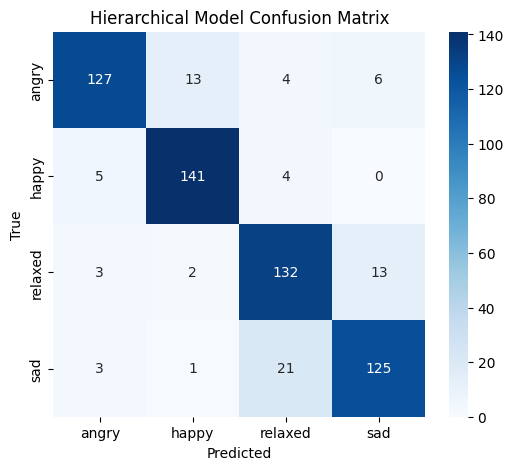

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Hierarchical Model Confusion Matrix")

plt.show()

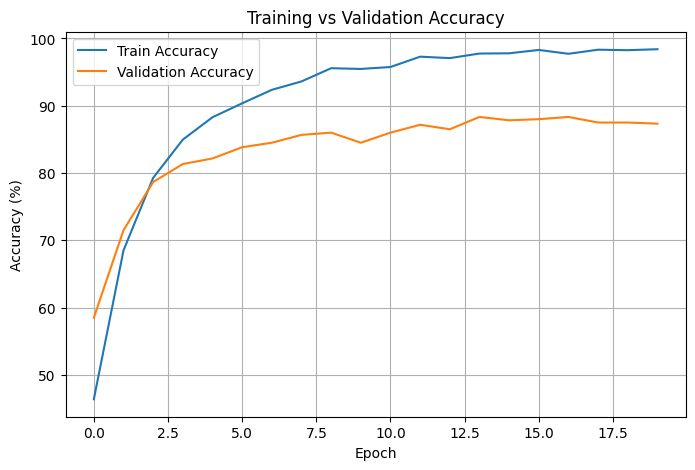

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

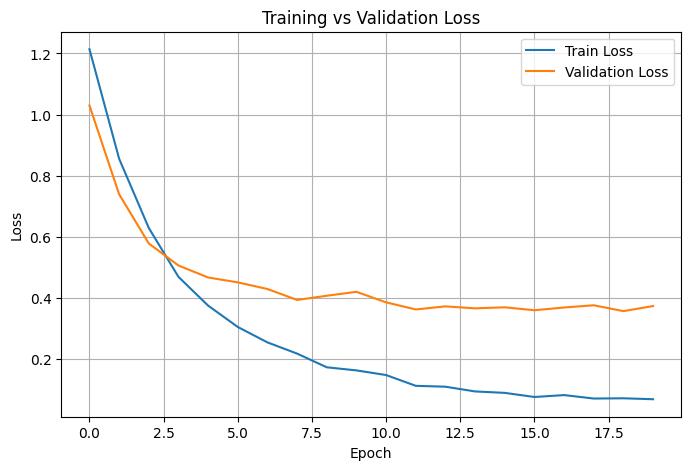

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
def relaxed_sad_subset(dataset):

    idx=[]
    for i in range(len(dataset)):
        _,label=dataset[i]
        if label in [2,3]:
            idx.append(i)

    return Subset(dataset,idx)

In [ ]:
rs_train=relaxed_sad_subset(train_dataset)
rs_test=relaxed_sad_subset(test_dataset)

rs_train_loader=DataLoader(rs_train,32,True)
rs_test_loader=DataLoader(rs_test,32)

In [ ]:
class RelaxedSadSpecialist(nn.Module):

    def __init__(self,stage1_model):
        super().__init__()

        self.extract_features=stage1_model.extract_features
        self.fc=nn.Linear(256,2)

    def forward(self,x):
        f=self.extract_features(x)
        return self.fc(f)

In [ ]:
specialist=RelaxedSadSpecialist(model).to(device)

criterion_rs=nn.CrossEntropyLoss()
optimizer_rs=torch.optim.AdamW(
    specialist.parameters(),
    lr=1e-4
)

In [ ]:
def remap(labels):
    labels=labels.clone()
    labels[labels==2]=0
    labels[labels==3]=1
    return labels

In [ ]:
for epoch in range(10):

    specialist.train()
    correct,total=0,0

    for images,labels in rs_train_loader:

        images=images.to(device)
        labels=remap(labels.to(device))

        optimizer_rs.zero_grad()

        logits=specialist(images)
        loss=criterion_rs(logits,labels)

        loss.backward()
        optimizer_rs.step()

        _,pred=torch.max(logits,1)

        total+=labels.size(0)
        correct+=(pred==labels).sum().item()

    print("Specialist:",100*correct/total)

Specialist: 55.07142857142857
Specialist: 91.5
Specialist: 98.71428571428571
Specialist: 99.14285714285714
Specialist: 99.21428571428571
Specialist: 99.14285714285714
Specialist: 99.5
Specialist: 99.42857142857143
Specialist: 99.42857142857143
Specialist: 99.35714285714286


In [ ]:
def hierarchical_predict(images):

    model.eval()
    specialist.eval()

    images = images.to(device)

    with torch.no_grad():

        # ---------- Stage 1 ----------
        logits = model(images)
        stage1_preds = torch.argmax(logits, dim=1)

        final_preds = stage1_preds.clone()

        # indices needing refinement
        mask = (stage1_preds == 2) | (stage1_preds == 3)

        if mask.sum() > 0:

            rs_images = images[mask]

            rs_logits = specialist(rs_images)
            rs_preds = torch.argmax(rs_logits, dim=1)

            # map back
            final_preds[mask] = torch.where(
                rs_preds == 0,
                torch.tensor(2, device=device),
                torch.tensor(3, device=device)
            )

    return final_preds

In [ ]:
changed_total = 0
routed_total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        # Stage-1 predictions
        logits = model(images)
        stage1_preds = torch.argmax(logits,1)

        # Hierarchical predictions
        final_preds = hierarchical_predict(images)

        routed_total += ((stage1_preds==2) |
                          (stage1_preds==3)).sum().item()

        changed_total += (stage1_preds != final_preds).sum().item()

print("Samples routed:", routed_total)
print("Predictions changed:", changed_total)

Samples routed: 305
Predictions changed: 7


In [ ]:
test_correct = 0
test_total = 0

all_preds = []
all_labels = []

model.eval()
specialist.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        # hierarchical prediction
        preds = hierarchical_predict(images)

        preds = preds.to(device)

        test_total += labels.size(0)
        test_correct += (preds == labels).sum().item()

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ----- FINAL ACCURACY -----
test_acc = 100 * test_correct / test_total

print(f"\n Hierarchical Test Accuracy: {test_acc:.2f}%")


 Hierarchical Test Accuracy: 87.50%


In [ ]:
from sklearn.metrics import classification_report

class_names = dataset.classes

print("\nHierarchical Classification Report:\n")

print(classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=4
))


Hierarchical Classification Report:

              precision    recall  f1-score   support

       angry     0.9203    0.8467    0.8819       150
       happy     0.8981    0.9400    0.9186       150
     relaxed     0.8199    0.8800    0.8489       150
         sad     0.8681    0.8333    0.8503       150

    accuracy                         0.8750       600
   macro avg     0.8766    0.8750    0.8749       600
weighted avg     0.8766    0.8750    0.8749       600



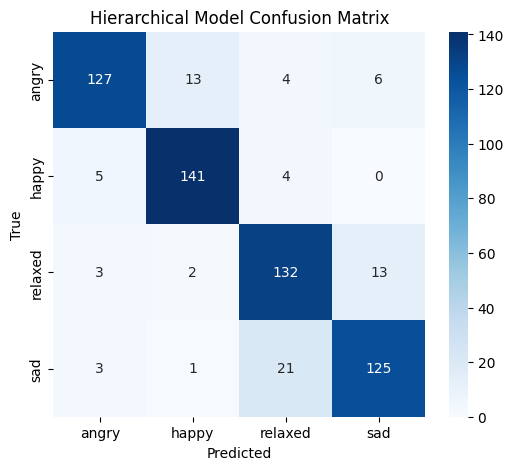

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Hierarchical Model Confusion Matrix")

plt.show()

In [ ]:
import shutil

shutil.copy(
    "/content/stage1_model.pth",
    "/content/drive/MyDrive/stage1_model.pth"
)

'/content/drive/MyDrive/stage1_model.pth'